# Эксперимент 7 (Трек 2): Предобуславливание HFN + оценка Хатчинсона

In [1]:
import time
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.datasets import load_svmlight_file

from oracles import LogCoshL2Oracle, ExponentialLossL2Oracle
from utils import get_line_search_tool

In [2]:
LIBSVM_BASE = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets"
data_dir = Path("data/libsvm")
data_dir.mkdir(parents=True, exist_ok=True)

def ensure_dataset(name, rel_url):
    path = data_dir / name
    if not path.exists():
        req = urllib.request.Request(f"{LIBSVM_BASE}/{rel_url}", headers={"User-Agent": "MetOpt-lab/2.0"})
        with urllib.request.urlopen(req, timeout=300) as r, open(path, "wb") as f:
            f.write(r.read())
    return path

def labels_pm_one(y):
    y = np.asarray(y, dtype=float).ravel()
    u = np.unique(y)
    if len(u) == 2 and 0.0 in u and 1.0 in u:
        return 2.0 * y - 1.0
    return y

def sparse_oracle_ops(X):
    if not sp.issparse(X):
        X = sp.csr_matrix(X, dtype=np.float64)
    else:
        X = X.astype(np.float64).tocsr()
    def matvec_Ax(x):
        return X.dot(np.asarray(x, dtype=np.float64).ravel())
    def matvec_ATx(v):
        return X.T.dot(np.asarray(v, dtype=np.float64).ravel())
    def matmat_ATsA(s):
        s = np.asarray(s, dtype=np.float64).ravel()
        return X.T.dot(sp.diags(s).dot(X)).toarray()
    return matvec_Ax, matvec_ATx, matmat_ATsA

clf_path = ensure_dataset("a9a", "binary/a9a")
X, y = load_svmlight_file(clf_path)
X = X.tocsr().astype(np.float64)
y = labels_pm_one(y)
m, n = X.shape
print(f"dataset shape: m={m}, n={n}")

dataset shape: m=32561, n=123


In [3]:
FAST_MODE = False
MAX_ROWS_FAST = 10000

X_work = X
y_work = y
if FAST_MODE and X.shape[0] > MAX_ROWS_FAST:
    idx = np.random.default_rng(78).choice(X.shape[0], size=MAX_ROWS_FAST, replace=False)
    X_work = X[idx]
    y_work = y[idx]

m_work, n_work = X_work.shape
X_bad = X_work.copy().tolil()
half = n_work // 2
if half > 0:
    X_bad[:, :half] = X_bad[:, :half] * 1000.0
    X_bad[:, half:] = X_bad[:, half:] * 0.001
X_bad = X_bad.tocsr()

regcoef = 1.0 / m_work
oracle = ExponentialLossL2Oracle(*sparse_oracle_ops(X_bad), y_work, regcoef)
x0 = np.zeros(n_work)

In [4]:
def hutchinson_diag_estimator(oracle, x, N=20, seed=None):
    """Оценка диагонали гессиана методом Хатчинсона с возможным усреднением по seed."""
    rng = np.random.default_rng(seed)
    n = x.size
    acc = np.zeros(n, dtype=np.float64)
    for _ in range(N):
        z = rng.choice([-1.0, 1.0], size=n)
        Hz = oracle.hess_vec(x, z)
        acc += z * Hz
    v = acc / N
    M_diag = np.maximum(np.abs(v), 1e-6)
    return M_diag

def pcg(matvec, b, x0, tol=1e-4, max_iter=None, M_diag=None):
    x = x0.copy()
    n = b.size
    if max_iter is None:
        max_iter = n
    r = b - matvec(x)
    b_norm = np.linalg.norm(b)
    if b_norm == 0:
        b_norm = 1.0
    if np.linalg.norm(r) <= tol * b_norm:
        return x, 0
    if M_diag is None:
        z = r.copy()
    else:
        z = r / M_diag
    p = z.copy()
    rz_old = np.dot(r, z)

    for k in range(1, max_iter + 1):
        Ap = matvec(p)
        denom = np.dot(p, Ap)
        if denom <= 1e-20:
            return x, k
        alpha = rz_old / denom
        x = x + alpha * p
        r = r - alpha * Ap
        if np.linalg.norm(r) <= tol * b_norm:
            return x, k
        if M_diag is None:
            z = r.copy()
        else:
            z = r / M_diag
        rz_new = np.dot(r, z)
        beta = rz_new / max(rz_old, 1e-32)
        p = z + beta * p
        rz_old = rz_new
    return x, max_iter

In [10]:
def hfn_run(oracle, x0, tol=1e-8, max_iter=40, line_search_options=None,
            use_precond=False, hutchinson_N=15, diag_update_freq=5):
    line_search_tool = get_line_search_tool(line_search_options)
    x = x0.copy()
    g = oracle.grad(x)
    g0_sq = np.dot(g, g)
    if g0_sq == 0:
        g0_sq = 1.0
    hist = {"time": [], "func": [], "grad_norm": [], "cg_iters": []}
    t0 = time.perf_counter()
    M_diag = None

    for iteration in range(max_iter):
        hist["time"].append(time.perf_counter() - t0)
        hist["func"].append(oracle.func(x))
        hist["grad_norm"].append(np.linalg.norm(g))
        rel_grad = np.dot(g, g) / g0_sq
        if rel_grad <= tol:
            break

        if use_precond and (iteration % diag_update_freq == 0):
            print(f"  Iter {iteration}: estimating diagonal with N={hutchinson_N} ...")
            M_diag = hutchinson_diag_estimator(oracle, x, N=hutchinson_N, seed=iteration)

        eta = min(0.5, np.sqrt(np.linalg.norm(g)))
        b_cg = -g
        hv = lambda v: oracle.hess_vec(x, v)
        d_init = -g

        d, cg_it = pcg(hv, b_cg, x0=d_init, tol=eta, max_iter=None, M_diag=M_diag)
        hist["cg_iters"].append(cg_it)

        # Проверка направления
        gd = np.dot(g, d)
        if gd >= 0:
            print(f"  Warning: non-descent direction (gd={gd:.2e}), using gradient")
            d = -g
            # Опционально: пересчитать cg_it = 0

        alpha = line_search_tool.line_search(oracle, x, d, previous_alpha=1.0)
        if alpha is None or alpha <= 0:
            alpha = 1e-4
        x = x + alpha * d
        g = oracle.grad(x)

    return x, hist

ls = {"method": "Wolfe", "c1": 1e-4, "c2": 0.9, "alpha_0": 1.0}

In [24]:
if FAST_MODE:
    tol_run = 1e-6
    max_iter_run = 20
    Ns = [5, 10, 50]
else:
    tol_run = 1e-8
    max_iter_run = 100
    Ns = [5, 10, 50]

x_base, h_base = hfn_run(oracle, x0, tol=tol_run, max_iter=max_iter_run, line_search_options=ls, use_precond=False)

precond_runs = {}
for N in Ns:
    xN, hN = hfn_run(oracle, x0, tol=tol_run, max_iter=max_iter_run, line_search_options=ls, use_precond=True, hutchinson_N=N)
    precond_runs[N] = (xN, hN)

print(f"done (FAST_MODE={FAST_MODE}, rows={m_work}, n={n_work})")

  Iter 0: estimating diagonal with N=5 ...


/home/misha/Документы/ITMO/2 курс/opt/metopt_lab_2_ExistanseOfNonExistent/utils.py:86: LineSearchWarning: The line search algorithm did not converge
  alpha_wolfe, _, _, _, _, _ = line_search(
/home/misha/.config/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


  Iter 5: estimating diagonal with N=5 ...
  Iter 10: estimating diagonal with N=5 ...
  Iter 15: estimating diagonal with N=5 ...
  Iter 20: estimating diagonal with N=5 ...
  Iter 25: estimating diagonal with N=5 ...
  Iter 30: estimating diagonal with N=5 ...
  Iter 35: estimating diagonal with N=5 ...
  Iter 40: estimating diagonal with N=5 ...
  Iter 45: estimating diagonal with N=5 ...
  Iter 50: estimating diagonal with N=5 ...
  Iter 55: estimating diagonal with N=5 ...
  Iter 0: estimating diagonal with N=10 ...
  Iter 5: estimating diagonal with N=10 ...
  Iter 10: estimating diagonal with N=10 ...
  Iter 15: estimating diagonal with N=10 ...
  Iter 20: estimating diagonal with N=10 ...
  Iter 25: estimating diagonal with N=10 ...
  Iter 30: estimating diagonal with N=10 ...
  Iter 35: estimating diagonal with N=10 ...
  Iter 40: estimating diagonal with N=10 ...
  Iter 45: estimating diagonal with N=10 ...
  Iter 50: estimating diagonal with N=10 ...
  Iter 55: estimating di

Графики сохранены в папку fig/


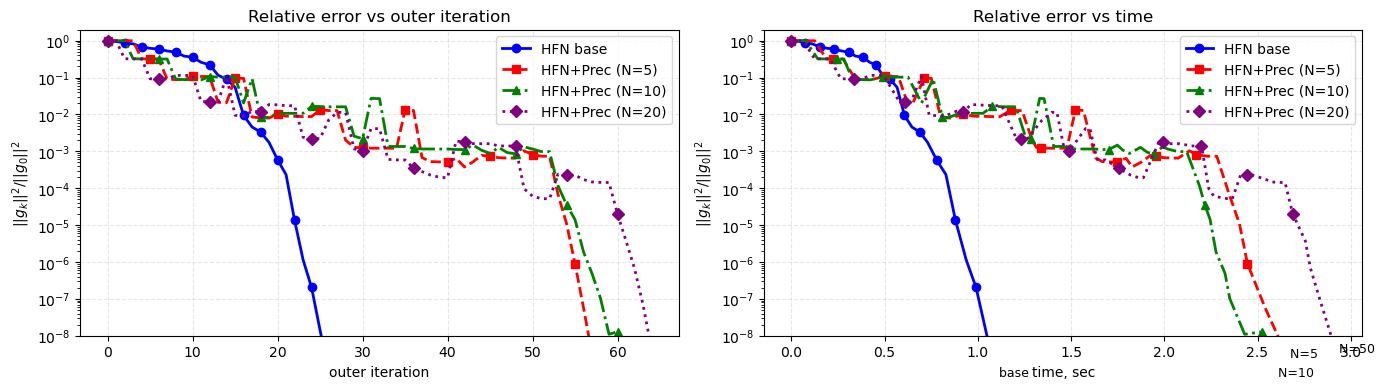

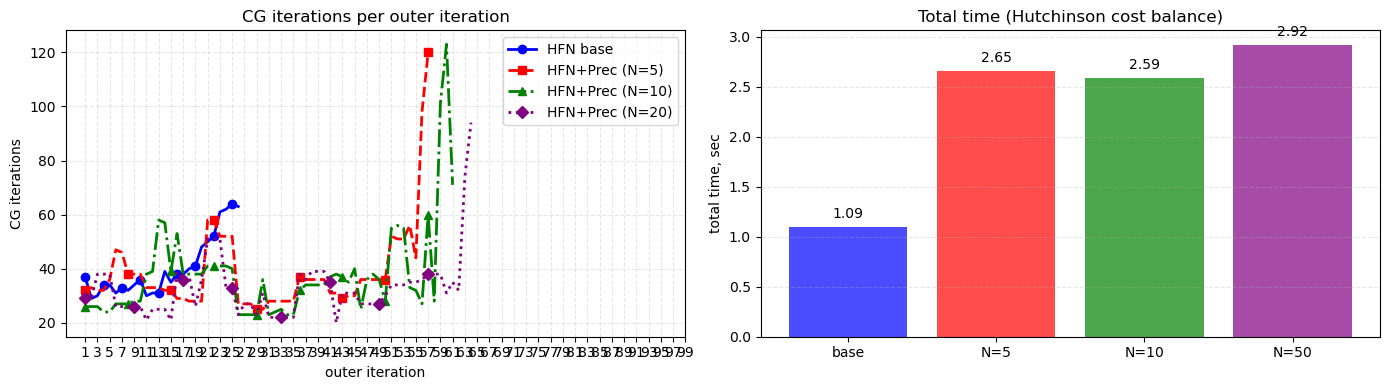

In [25]:
import matplotlib.pyplot as plt
import numpy as np

styles = {
    'base': {'marker': 'o', 'linestyle': '-', 'color': 'blue', 'label': 'HFN base', 'linewidth': 2},
    'N=5': {'marker': 's', 'linestyle': '--', 'color': 'red', 'label': 'HFN+Prec (N=5)', 'linewidth': 2},
    'N=10': {'marker': '^', 'linestyle': '-.', 'color': 'green', 'label': 'HFN+Prec (N=10)', 'linewidth': 2},
    'N=50': {'marker': 'D', 'linestyle': ':', 'color': 'purple', 'label': 'HFN+Prec (N=20)', 'linewidth': 2}
}

def rel_grad_sq(hist):
    g = np.array(hist["grad_norm"])
    return (g ** 2) / max(g[0] ** 2, 1e-32)

runs = [('base', h_base)] + [(f'N={N}', precond_runs[N][1]) for N in Ns]

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
for name, hist in runs:
    rel = rel_grad_sq(hist)
    its = np.arange(len(rel))
    plt.plot(its, rel, **styles[name], markersize=6, markevery=max(1, len(its)//10))
plt.yscale('log')
plt.xlabel('outer iteration')
plt.ylabel(r'$||g_k||^2 / ||g_0||^2$')
plt.title('Relative error vs outer iteration')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.ylim(1e-8, 2)

plt.subplot(1, 2, 2)
for name, hist in runs:
    times = hist['time']
    rel = rel_grad_sq(hist)
    plt.plot(times, rel, **styles[name], markersize=6, markevery=max(1, len(times)//10))
    plt.text(times[-1], rel[-1], f' {name}', fontsize=9, ha='left', va='center')
plt.yscale('log')
plt.xlabel('time, sec')
plt.ylabel(r'$||g_k||^2 / ||g_0||^2$')
plt.title('Relative error vs time')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.ylim(1e-8, 2)

plt.tight_layout()
plt.savefig('fig/exp7_hfn_error_curves.png', dpi=200, bbox_inches='tight')

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
for name, hist in runs:
    cg = hist['cg_iters']
    its = np.arange(1, len(cg)+1)
    plt.plot(its, cg, **styles[name], markersize=6, markevery=max(1, len(its)//8))
plt.xlabel('outer iteration')
plt.ylabel('CG iterations')
plt.title('CG iterations per outer iteration')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.xticks(np.arange(1, max_iter_run+1, 2))

plt.subplot(1, 2, 2)
labels = ['base'] + [f'N={N}' for N in Ns]
times_total = [h_base['time'][-1]] + [precond_runs[N][1]['time'][-1] for N in Ns]
bars = plt.bar(labels, times_total, color=['blue', 'red', 'green', 'purple'], alpha=0.7)
for bar, t in zip(bars, times_total):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02*max(times_total),
             f'{t:.2f}', ha='center', va='bottom', fontsize=10)
plt.ylabel('total time, sec')
plt.title('Total time (Hutchinson cost balance)')
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig/exp7_hfn_cg_and_time.png', dpi=200, bbox_inches='tight')

print("Графики сохранены в папку fig/")

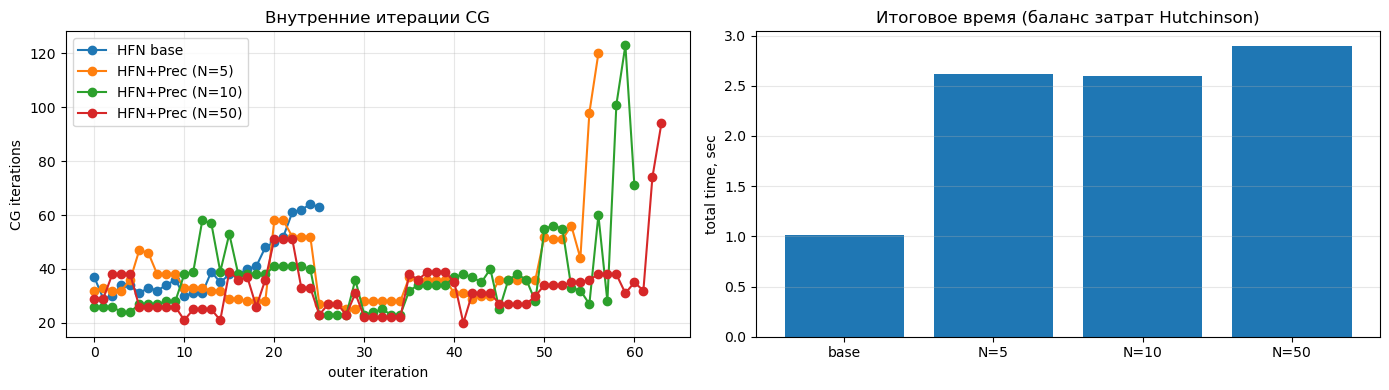

In [ ]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(h_base["cg_iters"], marker="o", label="HFN base")
for N, (_, hN) in precond_runs.items():
    plt.plot(hN["cg_iters"], marker="o", label=f"HFN+Prec (N={N})")
plt.xlabel("outer iteration")
plt.ylabel("CG iterations")
plt.title("Внутренние итерации CG")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
labels = ["base"] + [f"N={N}" for N in Ns]
vals = [h_base["time"][-1]] + [precond_runs[N][1]["time"][-1] for N in Ns]
plt.bar(labels, vals)
plt.ylabel("total time, sec")
plt.title("Итоговое время (баланс затрат Hutchinson)")
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
Path('fig').mkdir(parents=True, exist_ok=True)
plt.savefig('fig/exp7_hfn_cg_and_time.png', dpi=200, bbox_inches='tight')

In [20]:
print(f"Base total time: {h_base['time'][-1]:.10f} sec")
for N in Ns:
    print(f"N={N} total time: {precond_runs[N][1]['time'][-1]:.10f} sec")

Base total time: 1.0095456810 sec
N=5 total time: 2.6180933480 sec
N=10 total time: 2.5965230360 sec
N=50 total time: 2.8960936850 sec
